# Final Exam (part 3) - Computational Physics 2

### Deadline: Friday 6 June 2025 (by 23h59)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.


## 3. MPI Parallelisation of Molecular Dynamics Simulations

In this problem, you will use **Message Passing Interface (MPI)** library to parallelise the execution of molecular dynamics simulations for different temperatures. The goal is to distribute the simulation of various temperatures across multiple MPI processes, significantly reducing the overall computational time.

### Code:
The reference (serial) script can be found here:

https://github.com/wbandabarragan/computational-physics-2/blob/main/exams/thermostat.py

**You should only modify the code below the indicated line:**

`# Your MPI parallelization code should start here. Do not modify the code above.`

The core simulation logic within the `run` function should remain untouched.

### Tasks:

Use the provided script (`thermostat.py`) to create a new version of the script (`thermostat_mpi.py`) that uses the `mpi4py` library to parallelise the simulation execution. Here are the specific requirements for your MPI implementation:

**(a)** Set up a world communicator to distribute tasks among processes. Determine the rank of each process and the total number of processes.

**(b)** Distribute a range of temperatures among the available MPI processes. Each process should be responsible for running the simulation at one or more unique temperatures.

**(c)** Ensure proper initialization and finalization of the MPI environment. Cores should also send completion signals.

**(d)** The root/master process (rank 0) should handle workload communications and collect the simulation results from all other processes.

**(e)** For each simulated temperature, generate the `temperature-N_atoms.png` plot and the `traj-hydrogen-3D-N_atoms.dump` file. In addition the root/master process should:

- Collect and present the combined results (i.e., a single plot with all the temperature curves).

- Save the total execution time and the number of CPU cores used to a CSV file (`mpi_scaling.csv`). 

**(f)** Run the script with `mpirun` and different number of processors in an HPC facility.

---
As we were told to, everything was implemented in the `thermostat_mpi..py` file without modifiying the original code. Then, we copied it to CEDIA, and used the following script to run our parallel simulations:

```bash
#!/bin/bash
#SBATCH --job-name=thermo
#SBATCH --output=dot.out
#SBATCH --error=dot.err
#SBATCH --partition=cpu-max
#SBATCH --cpus-per-task=64
#SBATCH --time=4:00:00
#SBATCH --mem=32G

# Activate the environment
source ~/.bashrc
conda activate cptu

# --------------- PARALLEL RUNS ---------------
mpirun python thermostat_mpi.py -j 32 -n 32
mpirun python thermostat_mpi.py -j 16 -n 32
mpirun python thermostat_mpi.py -j 8 -n 32
mpirun python thermostat_mpi.py -j 4 -n 32
mpirun python thermostat_mpi.py -j 2 -n 32
mpirun python thermostat_mpi.py -j 1 -n 32
```

We set `N_atoms = 20000` and run $32$ simulations.

**Note:** I wrote my code so that the number of cores can be specficified with the `-j` flag, but I could (should?) have used the `-np` flag from `mpirun` to do it. I did that way becuase I just forgot about it, and I had already written the code to use the `-j` flag. The results are good, so I didn't change it.

---

### Scaling and analysis:

Report the simulation results (temperature plots and scaling) in this notebook:

**(g)** After running the MPI code for various numbers of CPU cores (e.g., 1, 2, 4, 8, 16, etc.), use the data accumulated in the CSV file (`mpi_scaling.csv`) from multiple runs to:

- Plot the observed speedup (e.g., $S_p = T_1 / T_p$, where $T_1$ is the execution time on 1 CPU and $T_p$ is the execution time on $p$ CPUs) as a function of the number of CPU cores.

- Compare your observed speedup to Amdahl's Law and discuss any discrepancies between the observed and theoretical speedup.

---
Instead of the speedup, I like to plot the time taken by each parallel run. It conveys the same information.

---

In [1]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
# Read csv
scaling = pd.read_csv('./cedia/mpi_scaling.csv')
scaling

,n_jobs,execution_time
0,32,39.177042
1,16,81.686435
2,8,163.422208
3,4,318.223403
4,2,637.274602
5,1,1279.270840


In [3]:
# Arrays
times = np.array(scaling['execution_time'])[::-1]
n_jobs = np.array(scaling['n_jobs'])[::-1]

In [4]:
# Ideal time
ideal_time = times[0] / n_jobs

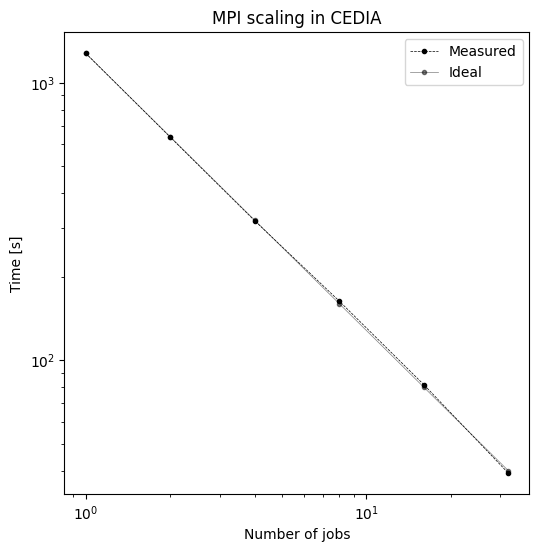

In [5]:
# Plot
plt.figure(figsize = (6, 6))
plt.plot(n_jobs, times, marker = '.', color = 'k', ls = '--', label = 'Measured', lw = 0.5)
plt.plot(n_jobs, ideal_time, marker = '.', color = 'k', ls = '-', label = 'Ideal', lw = 0.5, alpha = 0.5)

plt.loglog()

plt.xlabel('Number of jobs')
plt.ylabel('Time [s]')
plt.title('MPI scaling in CEDIA')

plt.legend()

plt.show()

The scaling results are close to perfection: we have achieved Amdahl's Law with a seemingly very small error.

Now we proceed to show some of the plots generated by the script in CEDIA.

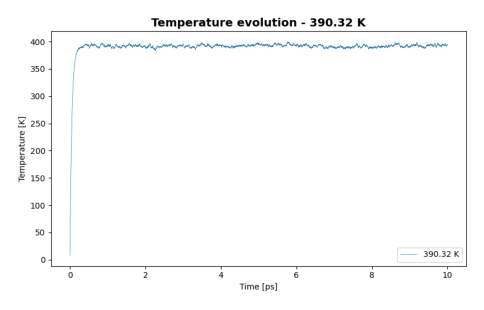

In [6]:
# From a simulation only
simulation = mpimg.imread('./cedia/temperature-20000-390.32.png')

plt.figure(figsize = (6, 6))
plt.imshow(simulation)
plt.axis('off')
plt.show()

We observe the system is stabilized at the target temperature and the fluctuations are small. The thermostat is working correctly.

Let's check the plot with all the simulations now.

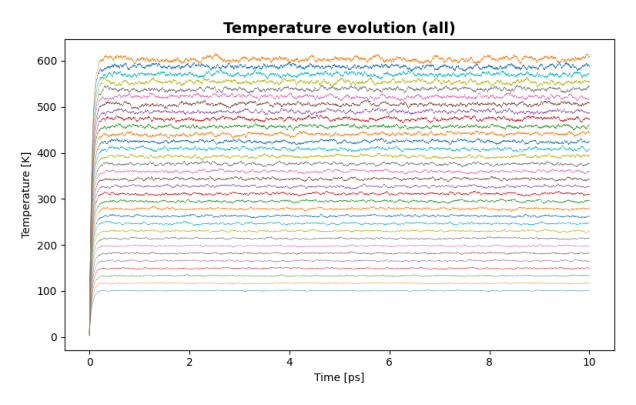

In [7]:
# All
filename_all = './cedia/temperature-a20000-all.png'
all_sims = mpimg.imread(filename_all)

plt.figure(figsize = (8, 5))
plt.imshow(all_sims)
plt.axis('off')
plt.show()

All simulations are close to the respective target. We also observe that the fluctuations become a little larger as the temperature increases.